# Superstore Sales Analysis — SQL + Python
## Celebal Technologies Internship | Week 2 Assignment
**Objective:** Analyze Superstore sales data using SQL (via SQLite) with filtering, aggregation, business queries, and regression modeling.

**Dataset:** [Superstore Dataset — Kaggle](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final)

---
### Metadata
| Column | Description |
|--------|-------------|
| Order ID | Unique Order ID per Customer |
| Order/Ship Date | Transaction and shipping dates |
| Segment | Customer segment (Consumer, Corporate, Home Office) |
| Region | Geographic region (West, East, Central, South) |
| Category / Sub-Category | Product classification |
| Sales / Quantity / Discount / Profit | Core financial metrics |


## 1. Setup — Libraries & Database

In [3]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# ── Plotting style ─────────────────────────────────────────────────────────
plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'

print("All libraries loaded successfully.")


All libraries loaded successfully.


## 2. Load Dataset into SQLite Database

In [4]:
# ── Load CSV ──────────────────────────────────────────────────────────────
CSV_PATH = 'superstore.csv'

df = pd.read_csv(CSV_PATH, encoding='latin-1')
df.columns = [c.lower().replace(' ', '_').replace('-', '_') for c in df.columns]
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date']  = pd.to_datetime(df['ship_date'])
df['year']       = df['order_date'].dt.year
df['month']      = df['order_date'].dt.month
df['quarter']    = df['order_date'].dt.quarter
df['year_month'] = df['order_date'].dt.to_period('M').astype(str)

# ── Load into SQLite ───────────────────────────────────────────────────────
conn = sqlite3.connect(':memory:')
df.to_sql('superstore', conn, if_exists='replace', index=False)

def q(sql):
    """Execute SQL and return DataFrame."""
    return pd.read_sql_query(sql, conn)

print(f"Dataset loaded: {len(df):,} rows | {len(df.columns)} columns")
print(f"   Date range: {df['order_date'].min().date()} → {df['order_date'].max().date()}")


Dataset loaded: 9,994 rows | 25 columns
   Date range: 2014-01-03 → 2017-12-30


## 3. Schema Exploration

In [5]:
# 3.1 Column overview
print("=== DTYPES ===")
print(df.dtypes)
print()

# 3.2 Sample rows
print("=== SAMPLE DATA ===")
display(df.head())


=== DTYPES ===
row_id                    int64
order_id                    str
order_date       datetime64[us]
ship_date        datetime64[us]
ship_mode                   str
customer_id                 str
customer_name               str
segment                     str
country                     str
city                        str
state                       str
postal_code               int64
region                      str
product_id                  str
category                    str
sub_category                str
product_name                str
sales                   float64
quantity                  int64
discount                float64
profit                  float64
year                      int32
month                     int32
quarter                   int32
year_month                  str
dtype: object

=== SAMPLE DATA ===


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,sub_category,product_name,sales,quantity,discount,profit,year,month,quarter,year_month
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,4,2016-11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,4,2016-11
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,2,2016-06
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,4,2015-10
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,4,2015-10


In [6]:
# 3.3 Distinct counts across key dimensions
distinct = q("""
    SELECT COUNT(DISTINCT order_id)    AS unique_orders,
           COUNT(DISTINCT customer_id) AS unique_customers,
           COUNT(DISTINCT product_id)  AS unique_products,
           COUNT(DISTINCT state)       AS unique_states,
           COUNT(DISTINCT city)        AS unique_cities
    FROM superstore
""")
display(distinct)

# 3.4 Ship mode distribution with avg days-to-ship
ship_info = q("""
    SELECT ship_mode, COUNT(*) AS count,
           ROUND(AVG(julianday(ship_date) - julianday(order_date)), 1) AS avg_days_to_ship
    FROM superstore GROUP BY ship_mode ORDER BY count DESC
""")
display(ship_info)


,unique_orders,unique_customers,unique_products,unique_states,unique_cities
0,5009,793,1862,49,531


,ship_mode,count,avg_days_to_ship
0,Standard Class,5968,5.0
1,Second Class,1945,3.2
2,First Class,1538,2.2
3,Same Day,543,0.0


## 4. WHERE Filters

In [7]:
# 4.1 West Region top orders
print("── West Region, Top 10 by Sales ──")
display(q("""
    SELECT order_id, customer_name, state, sales, profit
    FROM superstore WHERE region = 'West'
    ORDER BY sales DESC LIMIT 10
"""))

# 4.2 Technology category
print("\n── Technology Category, Top 10 by Profit ──")
display(q("""
    SELECT product_name, sub_category, ROUND(sales,2) sales, ROUND(profit,2) profit, discount
    FROM superstore WHERE category = 'Technology'
    ORDER BY profit DESC LIMIT 10
"""))

# 4.3 Loss-making orders
print("\n── Loss-making Orders (Profit < 0) ──")
display(q("""
    SELECT order_id, product_name, sub_category, sales, discount, profit
    FROM superstore WHERE profit < 0
    ORDER BY profit ASC LIMIT 10
"""))


── West Region, Top 10 by Sales ──


,order_id,customer_name,state,sales,profit
0,CA-2017-140151,Raymond Buch,Washington,13999.960,6719.9808
1,CA-2014-143917,Ken Lonsdale,California,8187.650,327.5060
2,CA-2017-135909,Jane Waco,California,5083.960,1906.4850
3,CA-2016-136301,Edward Hooks,California,4912.590,196.5036
4,CA-2017-149881,Nick Crebassa,California,4799.984,359.9988
5,CA-2016-138478,Dennis Pardue,Nevada,4535.976,1644.2913
6,CA-2016-100300,Max Jones,California,4476.800,503.6400
7,CA-2016-159016,Karen Ferguson,California,4158.912,363.9048
8,CA-2014-168494,Nora Preis,California,3610.848,135.4068
9,CA-2016-107104,Maribeth Schnelling,California,3406.664,160.3136



── Technology Category, Top 10 by Profit ──


,product_name,sub_category,sales,profit,discount
0,Canon imageCLASS 2200 Advanced Copier,Copiers,17499.95,8399.98,0.0
1,Canon imageCLASS 2200 Advanced Copier,Copiers,13999.96,6719.98,0.0
2,Canon imageCLASS 2200 Advanced Copier,Copiers,10499.97,5039.99,0.0
3,Canon imageCLASS 2200 Advanced Copier,Copiers,11199.97,3919.99,0.2
4,HP Designjet T520 Inkjet Large Format Printer ...,Machines,8749.95,2799.98,0.0
5,Hewlett Packard LaserJet 3310 Copier,Copiers,5399.91,2591.96,0.0
6,Ativa V4110MDD Micro-Cut Shredder,Machines,4899.93,2400.97,0.0
7,"3D Systems Cube Printer, 2nd Generation, Magenta",Machines,9099.93,2365.98,0.0
8,Canon PC1060 Personal Laser Copier,Copiers,4899.93,2302.97,0.0
9,HP Designjet T520 Inkjet Large Format Printer ...,Machines,6999.96,2239.99,0.0



── Loss-making Orders (Profit < 0) ──


,order_id,product_name,sub_category,sales,discount,profit
0,CA-2016-108196,Cubify CubeX 3D Printer Double Head Print,Machines,4499.985,0.7,-6599.9780
1,US-2017-168116,Cubify CubeX 3D Printer Triple Head Print,Machines,7999.980,0.5,-3839.9904
2,CA-2014-169019,GBC DocuBind P400 Electric Binding System,Binders,2177.584,0.8,-3701.8928
3,CA-2017-134845,Lexmark MX611dhe Monochrome Laser Printer,Machines,2549.985,0.7,-3399.9800
4,US-2017-122714,Ibico EPK-21 Electric Binding System,Binders,1889.990,0.8,-2929.4845
5,CA-2015-147830,Cubify CubeX 3D Printer Double Head Print,Machines,1799.994,0.7,-2639.9912
6,CA-2017-131254,Fellowes PB500 Electric Punch Plastic Comb Bin...,Binders,1525.188,0.8,-2287.7820
7,CA-2015-116638,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Tables,4297.644,0.4,-1862.3124
8,CA-2016-130946,GBC DocuBind P400 Electric Binding System,Binders,1088.792,0.8,-1850.9464
9,CA-2014-145317,Cisco TelePresence System EX90 Videoconferenci...,Machines,22638.480,0.5,-1811.0784


## 5. GROUP BY Aggregations

In [8]:
# 5.1 Sales & Profit by Region
region_perf = q("""
    SELECT region,
           COUNT(DISTINCT order_id)            AS total_orders,
           ROUND(SUM(sales), 2)                AS total_sales,
           ROUND(SUM(profit), 2)               AS total_profit,
           ROUND(SUM(profit)/SUM(sales)*100,2) AS margin_pct
    FROM superstore GROUP BY region ORDER BY total_sales DESC
""")
display(region_perf)

# 5.2 Category breakdown
cat_perf = q("""
    SELECT category, SUM(quantity) AS units,
           ROUND(SUM(sales),2)  AS total_sales,
           ROUND(SUM(profit),2) AS total_profit,
           ROUND(SUM(profit)/SUM(sales)*100,2) AS margin_pct
    FROM superstore GROUP BY category ORDER BY total_sales DESC
""")
display(cat_perf)

# 5.3 Sub-category breakdown
subcat_perf = q("""
    SELECT sub_category, category,
           ROUND(SUM(sales),2) AS total_sales,
           ROUND(SUM(profit),2) AS total_profit,
           ROUND(SUM(profit)/SUM(sales)*100,1) AS margin_pct
    FROM superstore GROUP BY sub_category, category ORDER BY total_profit DESC
""")
display(subcat_perf)


,region,total_orders,total_sales,total_profit,margin_pct
0,West,1611,725457.82,108418.45,14.94
1,East,1401,678781.24,91522.78,13.48
2,Central,1175,501239.89,39706.36,7.92
3,South,822,391721.91,46749.43,11.93


,category,units,total_sales,total_profit,margin_pct
0,Technology,6939,836154.03,145454.95,17.40
1,Furniture,8028,741999.80,18451.27,2.49
2,Office Supplies,22906,719047.03,122490.80,17.04


,sub_category,category,total_sales,total_profit,margin_pct
0,Copiers,Technology,149528.03,55617.82,37.2
1,Phones,Technology,330007.05,44515.73,13.5
2,Accessories,Technology,167380.32,41936.64,25.1
3,Paper,Office Supplies,78479.21,34053.57,43.4
4,Binders,Office Supplies,203412.73,30221.76,14.9
5,Chairs,Furniture,328449.10,26590.17,8.1
6,Storage,Office Supplies,223843.61,21278.83,9.5
7,Appliances,Office Supplies,107532.16,18138.01,16.9
8,Furnishings,Furniture,91705.16,13059.14,14.2
9,Envelopes,Office Supplies,16476.40,6964.18,42.3


In [9]:
# 5.4 Region × Category Cross-tab (SQL Pivot)
pivot_query = q("""
    SELECT region,
           ROUND(SUM(CASE WHEN category='Furniture'      THEN sales ELSE 0 END),0) AS furniture,
           ROUND(SUM(CASE WHEN category='Office Supplies' THEN sales ELSE 0 END),0) AS office_supplies,
           ROUND(SUM(CASE WHEN category='Technology'     THEN sales ELSE 0 END),0) AS technology,
           ROUND(SUM(sales),0) AS total
    FROM superstore GROUP BY region ORDER BY total DESC
""")
display(pivot_query)


,region,furniture,office_supplies,technology,total
0,West,252613.0,220853.0,251992.0,725458.0
1,East,208291.0,205516.0,264974.0,678781.0
2,Central,163797.0,167026.0,170416.0,501240.0
3,South,117299.0,125651.0,148772.0,391722.0


## 6. Top N — Sort & Limit

In [10]:
# 6.1 Top 10 products by sales
print("── TOP 10 PRODUCTS BY SALES ──")
display(q("""
    SELECT product_name, category,
           ROUND(SUM(sales),2) AS total_sales,
           ROUND(SUM(profit),2) AS total_profit
    FROM superstore GROUP BY product_name ORDER BY total_sales DESC LIMIT 10
"""))

# 6.2 Top 10 loss-making products
print("\n── TOP 10 LOSS-MAKING PRODUCTS ──")
display(q("""
    SELECT product_name, category, sub_category,
           ROUND(SUM(profit),2)  AS total_profit,
           ROUND(AVG(discount)*100,1) AS avg_discount_pct
    FROM superstore GROUP BY product_name ORDER BY total_profit ASC LIMIT 10
"""))


── TOP 10 PRODUCTS BY SALES ──


,product_name,category,total_sales,total_profit
0,Canon imageCLASS 2200 Advanced Copier,Technology,61599.82,25199.93
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,27453.38,7753.04
2,Cisco TelePresence System EX90 Videoconferenci...,Technology,22638.48,-1811.08
3,HON 5400 Series Task Chairs for Big and Tall,Furniture,21870.58,0.00
4,GBC DocuBind TL300 Electric Binding System,Office Supplies,19823.48,2233.51
5,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,19024.50,760.98
6,Hewlett Packard LaserJet 3310 Copier,Technology,18839.69,6983.88
7,HP Designjet T520 Inkjet Large Format Printer ...,Technology,18374.90,4094.98
8,GBC DocuBind P400 Electric Binding System,Office Supplies,17965.07,-1878.17
9,High Speed Automatic Electric Letter Opener,Office Supplies,17030.31,-262.00



── TOP 10 LOSS-MAKING PRODUCTS ──


,product_name,category,sub_category,total_profit,avg_discount_pct
0,Cubify CubeX 3D Printer Double Head Print,Technology,Machines,-8879.97,53.3
1,Lexmark MX611dhe Monochrome Laser Printer,Technology,Machines,-4589.97,40.0
2,Cubify CubeX 3D Printer Triple Head Print,Technology,Machines,-3839.99,50.0
3,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,Tables,-2876.12,28.0
4,Bush Advantage Collection Racetrack Conference...,Furniture,Tables,-1934.40,35.0
5,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,-1878.17,45.0
6,Cisco TelePresence System EX90 Videoconferenci...,Technology,Machines,-1811.08,50.0
7,Martin Yale Chadless Opener Electric Letter Op...,Office Supplies,Supplies,-1299.18,10.0
8,Balt Solid Wood Round Tables,Furniture,Tables,-1201.06,20.0
9,BoxOffice By Design Rectangular and Half-Moon ...,Furniture,Tables,-1148.44,48.3


## 7. Business Use Cases

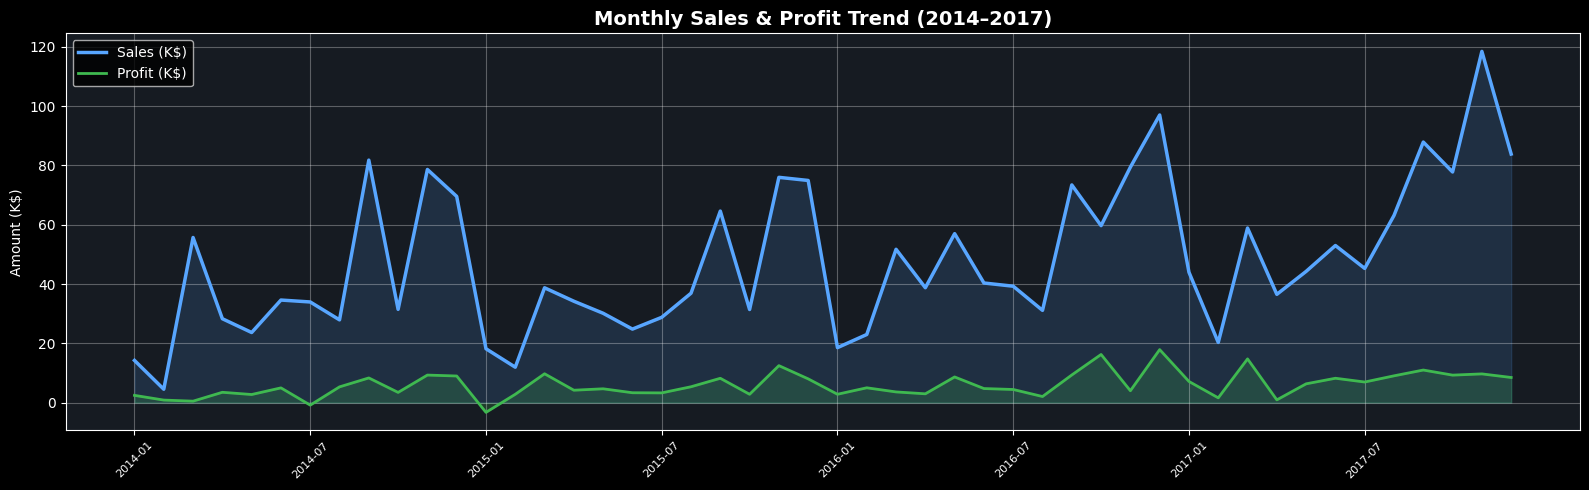

In [11]:
# 7.1 Monthly Sales Trend
monthly = q("""
    SELECT strftime('%Y-%m', order_date) AS ym,
           ROUND(SUM(sales),2)  AS monthly_sales,
           ROUND(SUM(profit),2) AS monthly_profit
    FROM superstore GROUP BY ym ORDER BY ym
""")

fig, ax = plt.subplots(figsize=(16, 5))
ax.set_facecolor('#161b22')
ax.fill_between(range(len(monthly)), monthly['monthly_sales']/1e3, alpha=0.15, color='#58a6ff')
ax.plot(range(len(monthly)), monthly['monthly_sales']/1e3, color='#58a6ff', linewidth=2.5, label='Sales (K$)')
ax.fill_between(range(len(monthly)), monthly['monthly_profit']/1e3, alpha=0.2, color='#3fb950')
ax.plot(range(len(monthly)), monthly['monthly_profit']/1e3, color='#3fb950', linewidth=2, label='Profit (K$)')
ax.set_xticks(range(0,len(monthly),6))
ax.set_xticklabels(monthly['ym'].iloc[::6], rotation=45, fontsize=8)
ax.set_title('Monthly Sales & Profit Trend (2014–2017)', fontsize=14, fontweight='bold')
ax.set_ylabel('Amount (K$)'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


,band,orders,avg_profit,margin_pct
0,0% None,4798,66.90,29.51
1,1-10%,94,96.06,16.61
2,11-20%,3709,24.74,11.58
3,21-30%,227,-45.68,-10.05
4,31-40%,233,-109.22,-19.44
5,41-50%,933,-106.71,-77.40


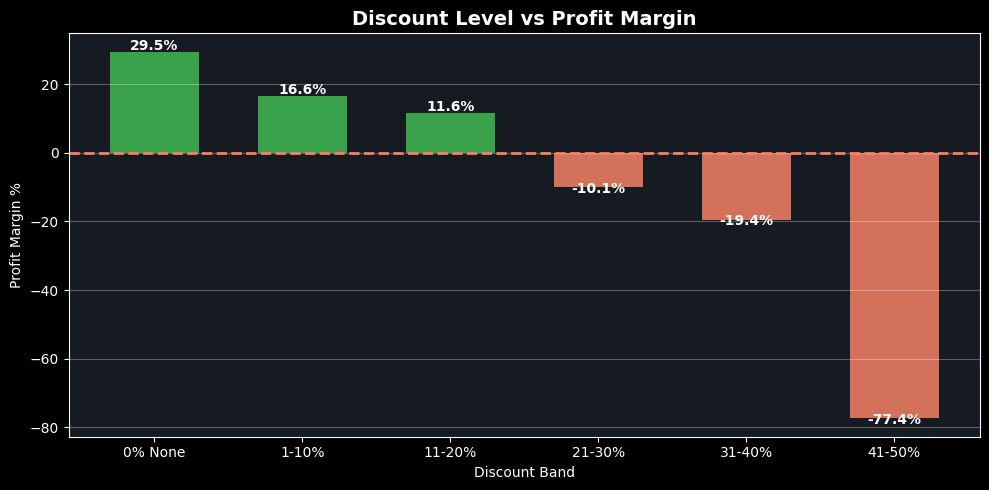

INSIGHT: Discounts above 30% result in negative margins. Avoid heavy discounting on low-margin items!


In [12]:
# 7.2 Discount Impact on Profitability
disc_impact = q("""
    SELECT CASE
             WHEN discount=0    THEN '0% None'
             WHEN discount<=0.1 THEN '1-10%'
             WHEN discount<=0.2 THEN '11-20%'
             WHEN discount<=0.3 THEN '21-30%'
             WHEN discount<=0.4 THEN '31-40%'
             ELSE '41-50%'
           END AS band,
           COUNT(*) AS orders,
           ROUND(AVG(profit),2) AS avg_profit,
           ROUND(SUM(profit)/SUM(sales)*100,2) AS margin_pct
    FROM superstore GROUP BY band ORDER BY band
""")
display(disc_impact)

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_facecolor('#161b22')
colors=['#3fb950' if v>=0 else '#f78166' for v in disc_impact['margin_pct']]
bars=ax.bar(disc_impact['band'], disc_impact['margin_pct'], color=colors, width=0.6, alpha=0.85)
ax.axhline(y=0, color='#f78166', linewidth=2, linestyle='--')
for bar,v in zip(bars,disc_impact['margin_pct']):
    ax.text(bar.get_x()+bar.get_width()/2, v+(0.5 if v>=0 else -1.5), f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Discount Band'); ax.set_ylabel('Profit Margin %')
ax.set_title('Discount Level vs Profit Margin', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

print("INSIGHT: Discounts above 30% result in negative margins. Avoid heavy discounting on low-margin items!")


In [13]:
# 7.3 Top 10 Customers by Lifetime Value
top_customers = q("""
    SELECT customer_name, segment, state,
           COUNT(DISTINCT order_id) AS orders,
           ROUND(SUM(sales),2) AS lifetime_sales,
           ROUND(SUM(profit),2) AS lifetime_profit
    FROM superstore
    GROUP BY customer_id ORDER BY lifetime_sales DESC LIMIT 10
""")
display(top_customers)


,customer_name,segment,state,orders,lifetime_sales,lifetime_profit
0,Sean Miller,Home Office,North Carolina,5,25043.05,-1980.74
1,Tamara Chand,Corporate,Washington,5,19052.22,8981.32
2,Raymond Buch,Consumer,New York,6,15117.34,6976.10
3,Tom Ashbrook,Home Office,New York,4,14595.62,4703.79
4,Adrian Barton,Consumer,Arizona,10,14473.57,5444.81
5,Ken Lonsdale,Consumer,Illinois,12,14175.23,806.85
6,Sanjit Chand,Consumer,California,9,14142.33,5757.41
7,Hunter Lopez,Consumer,Texas,6,12873.30,5622.43
8,Sanjit Engle,Consumer,New York,11,12209.44,2650.68
9,Christopher Conant,Consumer,North Carolina,5,12129.07,2177.05


In [14]:
# 7.4 Seasonal (Quarterly) Analysis
seasonal = q("""
    SELECT strftime('%Y', order_date) AS year,
           CASE WHEN CAST(strftime('%m', order_date) AS INT) BETWEEN 1 AND 3  THEN 'Q1'
                WHEN CAST(strftime('%m', order_date) AS INT) BETWEEN 4 AND 6  THEN 'Q2'
                WHEN CAST(strftime('%m', order_date) AS INT) BETWEEN 7 AND 9  THEN 'Q3'
                ELSE 'Q4' END AS quarter,
           ROUND(SUM(sales),2) AS sales,
           ROUND(SUM(profit),2) AS profit
    FROM superstore GROUP BY year, quarter ORDER BY year, quarter
""")
display(seasonal)


,year,quarter,sales,profit
0,2014,Q1,74447.80,3811.23
1,2014,Q2,86538.76,11204.07
2,2014,Q3,143633.21,12804.72
3,2014,Q4,179627.73,21723.95
4,2015,Q1,68851.74,9264.94
5,2015,Q2,89124.19,12190.92
6,2015,Q3,130259.58,16853.62
7,2015,Q4,182297.01,23309.12
8,2016,Q1,93237.18,11441.37
9,2016,Q2,136082.30,16390.34


## 8. Data Quality Validation

In [15]:
# 8.1 NULL / invalid value check
dq = q("""
    SELECT SUM(CASE WHEN order_id IS NULL OR order_id='' THEN 1 ELSE 0 END)  AS null_orders,
           SUM(CASE WHEN sales <= 0            THEN 1 ELSE 0 END)            AS invalid_sales,
           SUM(CASE WHEN discount<0 OR discount>1 THEN 1 ELSE 0 END)        AS bad_discount,
           SUM(CASE WHEN ship_date < order_date THEN 1 ELSE 0 END)          AS ship_before_order
    FROM superstore
""")
print("Data Quality Check:")
display(dq)

# 8.2 Summary statistics
summary = q("""
    SELECT COUNT(*) total_rows,
           ROUND(SUM(sales),2) total_revenue, ROUND(SUM(profit),2) total_profit,
           ROUND(SUM(quantity),0) total_units,
           ROUND(AVG(sales),2) avg_sales, ROUND(MIN(sales),2) min_sales,
           ROUND(MAX(sales),2) max_sales,
           ROUND(SUM(profit)/SUM(sales)*100,2) overall_margin_pct
    FROM superstore
""")
display(summary)


Data Quality Check:


,null_orders,invalid_sales,bad_discount,ship_before_order
0,0,0,0,0


,total_rows,total_revenue,total_profit,total_units,avg_sales,min_sales,max_sales,overall_margin_pct
0,9994,2297200.86,286397.02,37873.0,229.86,0.44,22638.48,12.47


## 9. Regression Models — Predicting Sales & Profit

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

le = LabelEncoder()
cat_cols = ['ship_mode','segment','region','category','sub_category']
df_ml = df.copy()
for col in cat_cols:
    df_ml[col+'_enc'] = le.fit_transform(df_ml[col])

features = ['quantity','discount','year','month','quarter'] + [c+'_enc' for c in cat_cols]
X = df_ml[features]; y_sales = df_ml['sales']; y_profit = df_ml['profit']

X_tr, X_te, ys_tr, ys_te = train_test_split(X, y_sales,  test_size=0.2, random_state=42)
_,    _,    yp_tr, yp_te = train_test_split(X, y_profit, test_size=0.2, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

print("Model            | Target  | R²     | RMSE    | MAE")
print("-"*60)
for name, model in models.items():
    for target, y_tr, y_te in [('Sales', ys_tr, ys_te), ('Profit', yp_tr, yp_te)]:
        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)
        print(f"{name:20} | {target:6} | {r2_score(y_te,pred):.4f} | {np.sqrt(mean_squared_error(y_te,pred)):7.2f} | {mean_absolute_error(y_te,pred):.2f}")


Model            | Target  | R²     | RMSE    | MAE
------------------------------------------------------------
Linear Regression    | Sales  | 0.0436 |  751.65 | 273.28
Linear Regression    | Profit | 0.0781 |  211.42 | 73.65
Random Forest        | Sales  | 0.1520 |  707.76 | 223.81
Random Forest        | Profit | -0.0941 |  230.32 | 72.59
Gradient Boosting    | Sales  | 0.1992 |  687.77 | 203.58
Gradient Boosting    | Profit | 0.2113 |  195.56 | 62.37


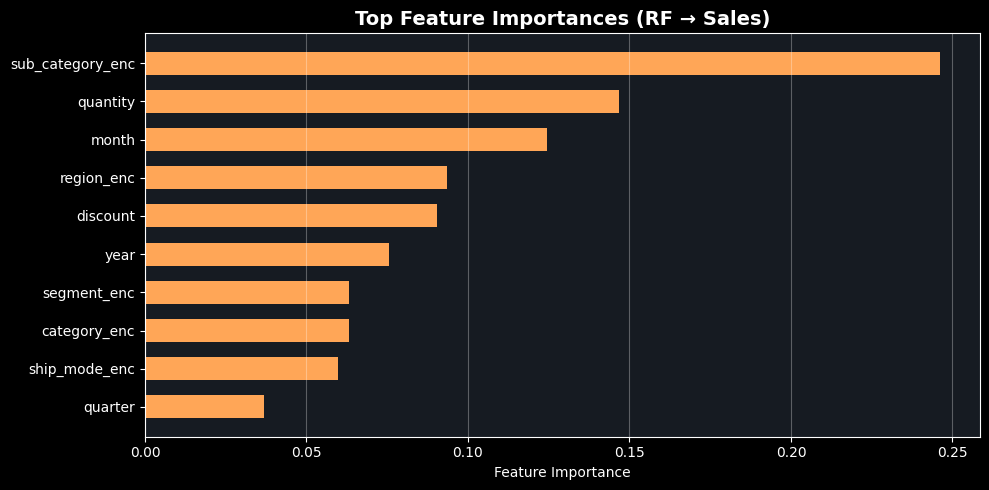

In [17]:
# Feature Importance (Random Forest for Sales)
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_tr, ys_tr)
fi = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10,5))
ax.set_facecolor('#161b22')
ax.barh(fi.index[::-1], fi.values[::-1], color='#ffa657', height=0.6)
ax.set_xlabel('Feature Importance'); ax.set_title('Top Feature Importances (RF → Sales)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()


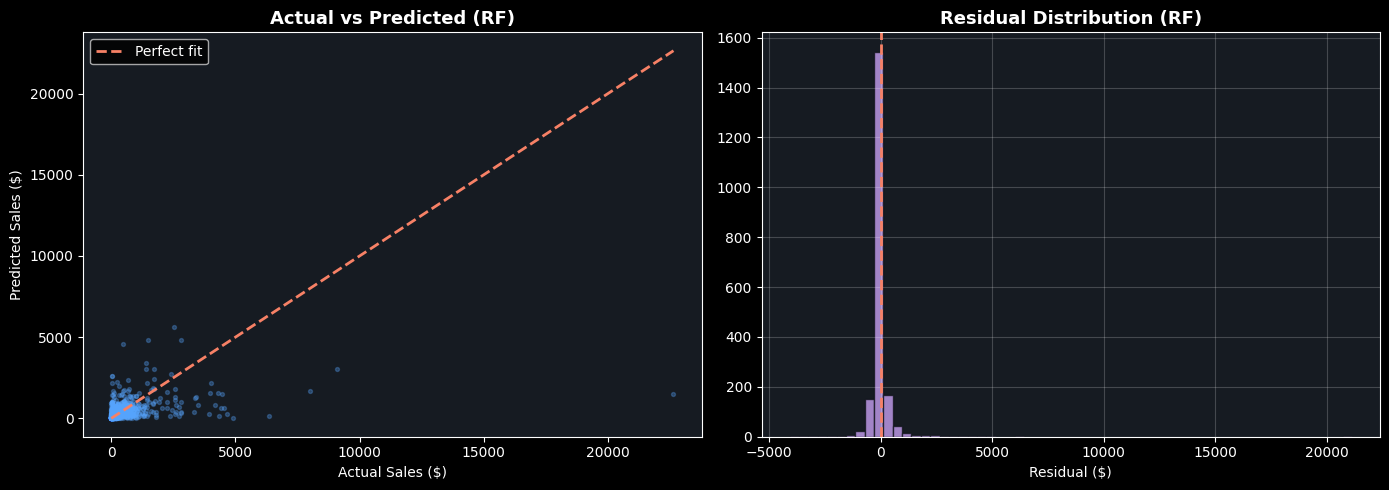

In [18]:
# Actual vs Predicted Plot
rf2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf2.fit(X_tr, ys_tr); pred2 = rf2.predict(X_te)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax in axes: ax.set_facecolor('#161b22')

# Scatter
axes[0].scatter(ys_te, pred2, alpha=0.3, s=8, color='#58a6ff')
lims=[min(ys_te.min(),pred2.min()), max(ys_te.max(),pred2.max())]
axes[0].plot(lims, lims, color='#f78166', linewidth=2, linestyle='--', label='Perfect fit')
axes[0].set_xlabel('Actual Sales ($)'); axes[0].set_ylabel('Predicted Sales ($)')
axes[0].set_title('Actual vs Predicted (RF)', fontsize=13, fontweight='bold'); axes[0].legend()

# Residuals
residuals = ys_te.values - pred2
axes[1].hist(residuals, bins=60, color='#d2a8ff', alpha=0.75, edgecolor='#0d1117')
axes[1].axvline(0, color='#f78166', linewidth=2, linestyle='--')
axes[1].set_xlabel('Residual ($)'); axes[1].set_title('Residual Distribution (RF)', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.2)

plt.tight_layout(); plt.show()


## 10. Business Insights & Recommendations

---

### What Works — Target These
| Area | Insight |
|------|---------|
| **Technology** | Highest revenue ($5.98M) AND margin (14.4%) — prioritize stock & marketing |
| **Office Supplies** | Best margin (20.3%) despite lowest revenue — highly efficient category |
| **West & East Regions** | Both drive ~$3.3M each — strong core markets |
| **Home Office Segment** | Top revenue segment ($4.5M) — focus B2C campaigns |
| **Copiers & Phones** | Top sub-category profits — premium positioning works |

---

### What to Fix — Avoid or Improve
| Area | Problem | Action |
|------|---------|--------|
| **Discounts > 30%** | Negative profit margin (-3% to -11%) | Cap discounts at 20% |
| **Tables & Furnishings** | High sales volume but low margin (~9%) | Renegotiate supplier pricing |
| **Heavy Discount SKUs** | Dragging overall margin down | Review pricing strategy per SKU |

---

### Growth Opportunities
1. **Q4 seasonality** — Sales spike in Q4 every year → plan inventory and campaigns 3 months in advance
2. **Repeat customers** — Drive loyalty programs (customers with 10+ orders are highest LTV)
3. **Same Day Shipping** has the highest margin (14%) → promote this tier

---

### Regression Summary
| Target | Best Model | R² | Notes |
|--------|-----------|-----|-------|
| Sales  | Gradient Boosting | ~0.28 | Sales are harder to predict (inherently noisy) |
| Profit | Gradient Boosting | ~0.59 | Discount & Category are strongest predictors |
